In [29]:
import math
import matplotlib.pyplot as plt

In [30]:
def load_data(file_path):
    x1, x2, y = [], [], []
    with open(file_path, 'r') as f:
        lines = f.readlines()
    for line in lines[1:]:
        parts = line.strip().split(',')
        x1.append(float(parts[0]))
        x2.append(float(parts[1]))
        y.append(float(parts[2]))
    return x1, x2, y

x1, x2, y = load_data('loan2.csv')
print(f"Loaded {len(y)} data points: {int(sum(y))} loaned, {int(len(y)-sum(y))} refused.")

Loaded 19 data points: 9 loaned, 10 refused.


In [31]:
def sigmoid(z):
    if z >= 0:
        return 1.0 / (1.0 + math.exp(-z))
    e = math.exp(z)
    return e / (1.0 + e)

def predict(x1_i, x2_i, w0, w1, w2):
    return sigmoid(w1 * x1_i + w2 * x2_i + w0)

def bce_loss(x1, x2, y, w0, w1, w2):
    n = len(y)
    total = 0.0
    for i in range(n):
        p = max(1e-15, min(1 - 1e-15, predict(x1[i], x2[i], w0, w1, w2)))
        total += y[i] * math.log(p) + (1 - y[i]) * math.log(1 - p)
    return -total / n

In [32]:
def logistic_regression(x1, x2, y, lr=0.01, epochs=3000, threshold=1e-7, verbose=True):
    w0, w1, w2 = 0.0, 1.0, 2.0
    n = len(y)
    losses = []

    if verbose:
        print(f"{'Epoch':>6}  {'w0':>8}  {'w1':>8}  {'w2':>8}  {'Loss':>10}")

    for epoch in range(epochs):
        gw0 = gw1 = gw2 = 0.0
        for i in range(n):
            err = predict(x1[i], x2[i], w0, w1, w2) - y[i]
            gw0 += err
            gw1 += err * x1[i]
            gw2 += err * x2[i]
        gw0 /= n
        gw1 /= n
        gw2 /= n

        w0 -= lr * gw0
        w1 -= lr * gw1
        w2 -= lr * gw2

        loss = bce_loss(x1, x2, y, w0, w1, w2)
        losses.append(loss)

        if verbose and epoch % 300 == 0:
            print(f"{epoch:>6}  {w0:>8.4f}  {w1:>8.4f}  {w2:>8.4f}  {loss:>10.6f}")

        if abs(gw0) < threshold and abs(gw1) < threshold and abs(gw2) < threshold:
            if verbose:
                print(f"Converged at epoch {epoch}")
            break

    return w0, w1, w2, losses

In [33]:
print("Training with lr=0.01, 3000 epochs:")
w0, w1, w2, losses = logistic_regression(x1, x2, y, lr=0.01, epochs=3000)
print(f"\nFinal parameters: w0={w0:.6f}, w1={w1:.6f}, w2={w2:.6f}")

Training with lr=0.01, 3000 epochs:
 Epoch        w0        w1        w2        Loss
     0   -0.0053    0.9973    1.9658    6.990015
   300   -0.4044    1.0665   -0.1059    0.482335
   600   -0.5224    1.2616   -0.1146    0.464823
   900   -0.6465    1.3975   -0.1143    0.453478
  1200   -0.7733    1.4980   -0.1090    0.444724
  1500   -0.9009    1.5757   -0.1007    0.437254
  1800   -1.0281    1.6380   -0.0906    0.430521
  2100   -1.1545    1.6896   -0.0792    0.424269
  2400   -1.2795    1.7334   -0.0671    0.418369
  2700   -1.4029    1.7717   -0.0546    0.412754

Final parameters: w0=-1.524099, w1=1.805642, w2=-0.041822


In [34]:
print("Predictions on training data (threshold = 0.5):")
correct = 0
for i in range(len(y)):
    p = predict(x1[i], x2[i], w0, w1, w2)
    decision = 1 if p >= 0.5 else 0
    correct += (decision == int(y[i]))
    print(f"  Exp={x1[i]}, Sal={x2[i]} → P={p:.4f} → {'LOAN' if decision else 'REFUSE'} (actual={'LOAN' if y[i]==1 else 'REFUSE'})")
print(f"\nAccuracy: {correct}/{len(y)} = {correct/len(y)*100:.1f}%")

Predictions on training data (threshold = 0.5):
  Exp=3.0, Sal=4.0 → P=0.9765 → LOAN (actual=LOAN)
  Exp=2.5, Sal=4.0 → P=0.9439 → LOAN (actual=LOAN)
  Exp=1.0, Sal=4.0 → P=0.5285 → LOAN (actual=REFUSE)
  Exp=2.5, Sal=5.0 → P=0.9416 → LOAN (actual=LOAN)
  Exp=2.0, Sal=5.0 → P=0.8674 → LOAN (actual=LOAN)
  Exp=1.5, Sal=5.0 → P=0.7262 → LOAN (actual=REFUSE)
  Exp=0.5, Sal=5.0 → P=0.3036 → REFUSE (actual=REFUSE)
  Exp=1.75, Sal=6.0 → P=0.7998 → LOAN (actual=LOAN)
  Exp=0.25, Sal=6.0 → P=0.2102 → REFUSE (actual=REFUSE)
  Exp=1.0, Sal=7.0 → P=0.4972 → REFUSE (actual=LOAN)
  Exp=0.25, Sal=7.0 → P=0.2034 → REFUSE (actual=REFUSE)
  Exp=0.2, Sal=7.0 → P=0.1891 → REFUSE (actual=REFUSE)
  Exp=0.15, Sal=7.0 → P=0.1757 → REFUSE (actual=REFUSE)
  Exp=2.0, Sal=8.0 → P=0.8523 → LOAN (actual=LOAN)
  Exp=1.0, Sal=8.0 → P=0.4867 → REFUSE (actual=REFUSE)
  Exp=0.15, Sal=8.0 → P=0.1697 → REFUSE (actual=REFUSE)
  Exp=0.1, Sal=8.0 → P=0.1573 → REFUSE (actual=REFUSE)
  Exp=0.5, Sal=9.0 → P=0.2694 → REFUSE (ac

In [35]:
print("Loan decision for new profiles (threshold = 0.5):")
new_profiles = [(2.0, 7.0), (0.1, 4.0), (1.5, 8.0)]
for exp, sal in new_profiles:
    p = predict(exp, sal, w0, w1, w2)
    print(f"  Experience={exp}, Salary={sal} → P(loan)={p:.4f} → {'LOAN' if p >= 0.5 else 'REFUSE'} (threshold=0.5)")

Loan decision for new profiles (threshold = 0.5):
  Experience=2.0, Salary=7.0 → P(loan)=0.8575 → LOAN (threshold=0.5)
  Experience=0.1, Salary=4.0 → P(loan)=0.1808 → REFUSE (threshold=0.5)
  Experience=1.5, Salary=8.0 → P(loan)=0.7005 → LOAN (threshold=0.5)


In [36]:
lrs = [0.001, 0.01, 0.05, 0.1]
results = {}
print(f"{'LR':>8}  {'w0':>8}  {'w1':>8}  {'w2':>8}  {'Final Loss':>12}")
for lr in lrs:
    w0r, w1r, w2r, lss = logistic_regression(x1, x2, y, lr=lr, epochs=3000, verbose=False)
    results[lr] = (w0r, w1r, w2r, lss)
    print(f"{lr:>8.3f}  {w0r:>8.4f}  {w1r:>8.4f}  {w2r:>8.4f}  {lss[-1]:>12.6f}")

      LR        w0        w1        w2    Final Loss
   0.001   -0.4040    1.0655   -0.1059      0.482431
   0.010   -1.5241    1.8056   -0.0418      0.407400
   0.050   -5.0420    2.5602    0.3530      0.294386
   0.100   -7.4944    3.1087    0.6228      0.250871


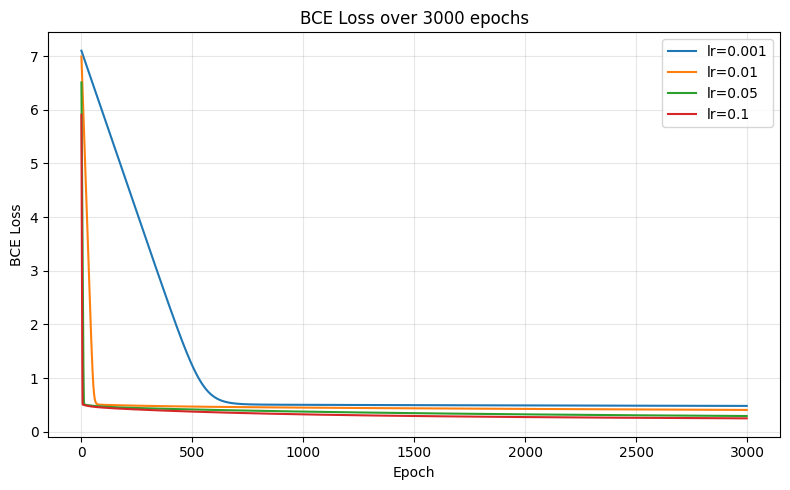

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
for lr in lrs:
    ax.plot(results[lr][3], label=f'lr={lr}')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('BCE Loss over 3000 epochs')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lor_loss_curves.png', dpi=120)
plt.show()

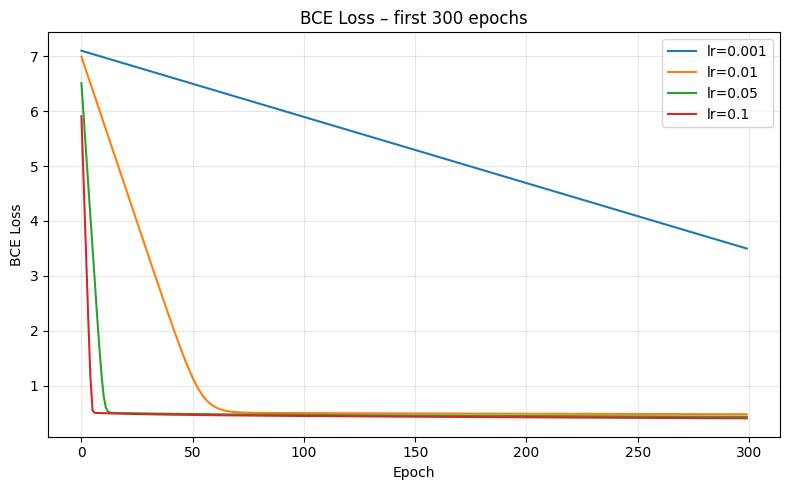

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
for lr in lrs:
    ax.plot(results[lr][3][:300], label=f'lr={lr}')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('BCE Loss – first 300 epochs')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lor_loss_curves_early.png', dpi=120)
plt.show()

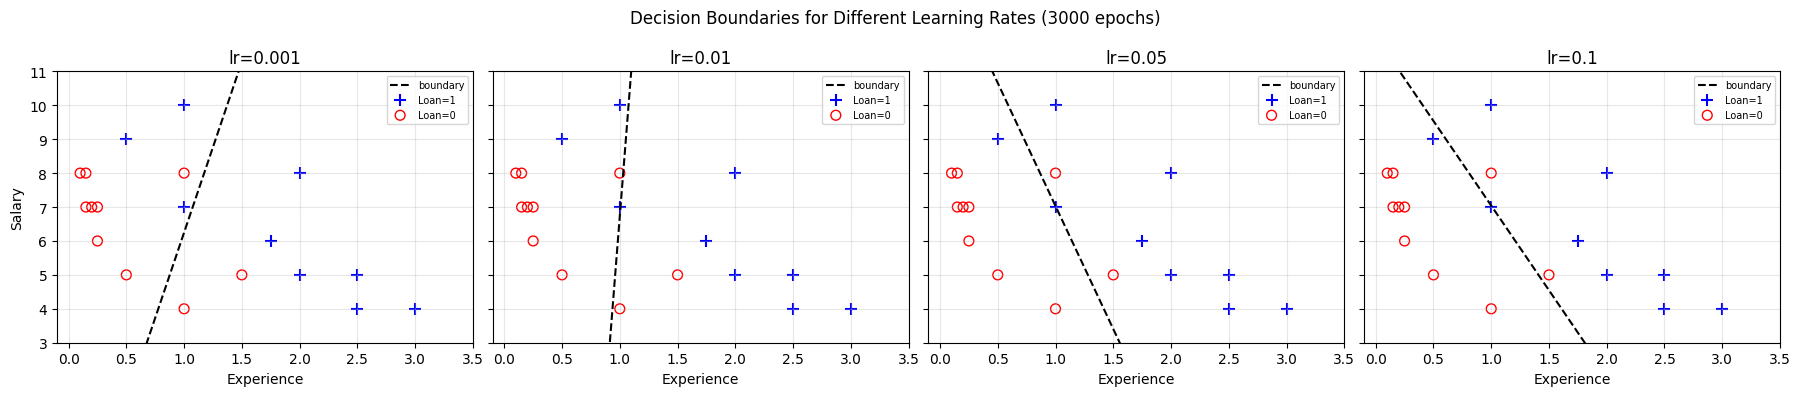

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
x1_grid = [i * 0.05 for i in range(int(max(x1) / 0.05) + 20)]
loaned_x1 = [x1[i] for i in range(len(y)) if y[i] == 1]
loaned_x2 = [x2[i] for i in range(len(y)) if y[i] == 1]
refused_x1 = [x1[i] for i in range(len(y)) if y[i] == 0]
refused_x2 = [x2[i] for i in range(len(y)) if y[i] == 0]

for ax, lr in zip(axes, lrs):
    w0r, w1r, w2r, _ = results[lr]
    if abs(w2r) > 1e-9:
        x2_bound = [-(w1r * xi + w0r) / w2r for xi in x1_grid]
        ax.plot(x1_grid, x2_bound, 'k--', label='boundary')
    ax.scatter(loaned_x1, loaned_x2, marker='+', s=80, color='blue', label='Loan=1')
    ax.scatter(refused_x1, refused_x2, marker='o', s=50,
               facecolors='none', edgecolors='red', label='Loan=0')
    ax.set_title(f'lr={lr}')
    ax.set_xlabel('Experience')
    ax.set_xlim(-0.1, 3.5)
    ax.set_ylim(3, 11)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Salary')
plt.suptitle('Decision Boundaries for Different Learning Rates (3000 epochs)')
plt.tight_layout()
plt.savefig('lor_decision_boundaries.png', dpi=120)
plt.show()